
 # Financial Transactions Dataset: Analytics and Fraud Detection

## Data understanding

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("computingvictor/transactions-fraud-datasets")

print("Path to dataset files:", path)

100%|██████████| 348M/348M [00:27<00:00, 13.4MB/s] 

Extracting files...


Path to dataset files: C:\Users\Christina\.cache\kagglehub\datasets\computingvictor\transactions-fraud-datasets\versions\1


In [29]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import json



In [2]:
df_cards = pd.read_csv('cards_data.csv')
df_cards

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,5361,185,Amex,Credit,300609782832003,01/2024,663,YES,1,$6900,11/2000,2013,No
6142,2711,185,Visa,Credit,4718517475996018,01/2021,492,YES,2,$5700,04/2012,2012,No
6143,1305,1007,Mastercard,Credit,5929512204765914,08/2020,237,NO,2,$9200,02/2012,2012,No
6144,743,1110,Mastercard,Debit,5589768928167462,01/2020,630,YES,1,$28074,01/2020,2020,No


In [3]:
df_cards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   int64 
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   object
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(6), object(7)
memory usage: 624.3+ KB


In [4]:
df_transaction = pd.read_csv('transactions_data.csv')
df_transaction.head(5)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


In [5]:
df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   client_id       int64  
 3   card_id         int64  
 4   amount          object 
 5   use_chip        object 
 6   merchant_id     int64  
 7   merchant_city   object 
 8   merchant_state  object 
 9   zip             float64
 10  mcc             int64  
 11  errors          object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.2+ GB


In [39]:
with open('train_fraud_labels.json') as f:
    fraud_labels = json.load(f)['target']

df_isFraud = pd.DataFrame(
    fraud_labels.items(),
    columns=['id','is_fraud']
)

df_isFraud.head()

,id,is_fraud
0,10649266,No
1,23410063,No
2,9316588,No
3,12478022,No
4,9558530,No


In [40]:
df_isFraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 2 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   id        object
 1   is_fraud  object
dtypes: object(2)
memory usage: 136.0+ MB


## Data Cleaning

In [ ]:
# df_isFraud
# Make is_fraud boolean
df_isFraud['is_fraud'] = df_isFraud['is_fraud'].map({
    'Yes': True,
    'No': False
})

In [42]:
df_isFraud['id'] = df_isFraud['id'].astype('int64')

In [43]:
print(df_isFraud.head())
print('----------')
print(df_isFraud.info())


         id  is_fraud
0  10649266     False
1  23410063     False
2   9316588     False
3  12478022     False
4   9558530     False
----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 2 columns):
 #   Column    Dtype
---  ------    -----
 0   id        int64
 1   is_fraud  bool 
dtypes: bool(1), int64(1)
memory usage: 76.5 MB
None


In [67]:
# df_transaction

df_transaction['date'] = pd.to_datetime(df_transaction['date'])
df_transaction['amount'] = pd.to_numeric(df_transaction['amount'].str.replace('$','', regex=False), errors='coerce')

In [74]:
df_transaction['use_chip'].value_counts()

use_chip
Swipe Transaction     6967185
Chip Transaction      4780818
Online Transaction    1557912
Name: count, dtype: int64

In [75]:
# Connect mcc code to df_transactions dataframe

with open('mcc_codes.json') as f:
    mcc_codes = json.load(f)

df_transaction['mcc'] = df_transaction['mcc'].astype(str).map(mcc_codes)

In [77]:
df_transaction['mcc']

0                            Miscellaneous Food Stores
1                                    Department Stores
2                                       Money Transfer
3                                       Money Transfer
4                Drinking Places (Alcoholic Beverages)
                               ...                    
13305910                     Miscellaneous Food Stores
13305911            Digital Goods - Media, Books, Apps
13305912    Utilities - Electric, Gas, Water, Sanitary
13305913                  Grocery Stores, Supermarkets
13305914            Package Stores, Beer, Wine, Liquor
Name: mcc, Length: 13305915, dtype: object

In [96]:
df_transaction.head(3)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,Miscellaneous Food Stores,NaN
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,Department Stores,NaN
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,Money Transfer,NaN


In [97]:
fraud_merchant = df_transaction.merge(df_isFraud,on='id',how='left')
fraud_merchant.head(3)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,is_fraud
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,Miscellaneous Food Stores,NaN,False
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,Department Stores,NaN,False
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,Money Transfer,NaN,False


In [ ]:
# Chech the 2 Datasets seperately
df_fraudTransaction = fraud_merchant[fraud_merchant['is_fraud'] == True]
df_nonFraudTransaction = fraud_merchant[fraud_merchant['is_fraud'] == False]

In [104]:
comparison_amount = pd.DataFrame({
    "Fraud": df_fraudTransaction["amount"].describe(),
    "Non-Fraud": df_nonFraudTransaction["amount"].describe()
})

comparison_amount

,Fraud,Non-Fraud
count,13332.000000,8.901631e+06
mean,110.234682,4.284861e+01
std,213.736207,8.112535e+01
min,-500.000000,-5.000000e+02
25%,17.835000,8.920000e+00
50%,69.975000,2.895000e+01
75%,148.492500,6.357000e+01
max,4978.450000,6.613440e+03


## Data Visualization

##### Fraud Vs Non-Fraud Count Plot

In [ ]:
fraud_count = df_isFraud['is_fraud'].value_counts()
fraud_count

is_fraud
False    8901631
True       13332
Name: count, dtype: int64

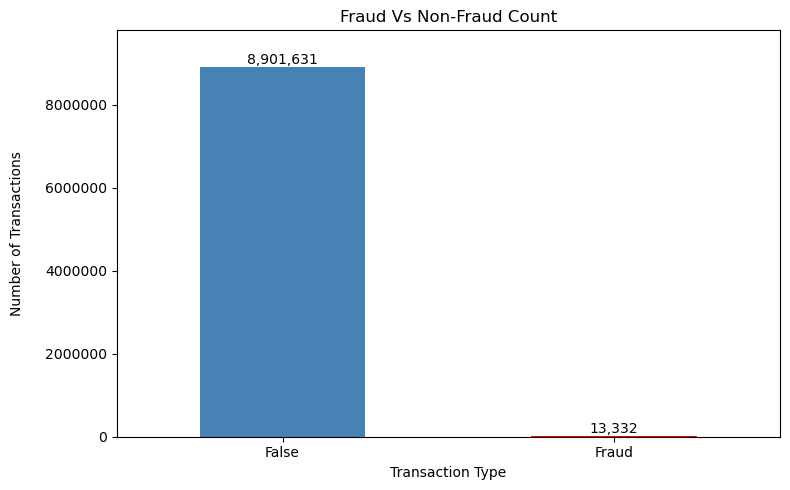

In [ ]:
# Fraud Vs Non-Fraud Count Plot
plt.figure(figsize=(8, 5))

fraud_count_plot = fraud_count.rename({
    False: 'Non-Fraud',
    True: 'Fraud'
})

ax = fraud_count_plot.plot(
    kind="bar",
    color=["steelblue", "red"]
)

plt.title("Fraud Vs Non-Fraud Count")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions", rotation=90, labelpad=15)
plt.xticks(rotation=0)
plt.ticklabel_format(style="plain", axis="y")
plt.ylim(0, fraud_count_plot.max() * 1.10)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

##### Fraud Percentage

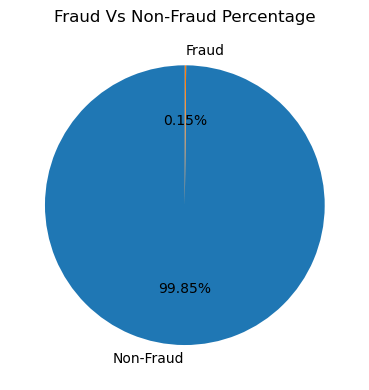

In [62]:
# Fraud Percentage
fraud_percentage = df_isFraud['is_fraud'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))

fraud_percentage = fraud_percentage.rename({
    False: "Non-Fraud",
    True: "Fraud"
})

fraud_percentage.plot(
    kind='pie',
    autopct='%1.2f%%',
    startangle=90,
    ylabel=''
)

plt.title('Fraud Vs Non-Fraud Percentage')
plt.tight_layout()
plt.show()

##### Fraud Vs Merchant 

In [79]:
# Fraud Vs Merchant 
fraud_merchant = df_transaction.merge(df_isFraud,on='id',how='left')
fraud_merchant.value_counts()

id        date                 client_id  card_id  amount   use_chip           merchant_id  merchant_city   merchant_state  zip      mcc                                    errors                is_fraud
7475792   2010-01-01 07:02:00  1424       4710     -72.00   Swipe Transaction  59935        Kingman         AZ              86401.0  Miscellaneous Food Stores              Insufficient Balance  False       1
18250175  2016-08-19 08:41:00  1047       3999      95.01   Chip Transaction   11468        Virginia Beach  VA              23454.0  Artist Supply Stores, Craft Shops      Insufficient Balance  False       1
18249894  2016-08-19 07:35:00  1696       2408      76.00   Chip Transaction   59935        Merritt Island  FL              32953.0  Miscellaneous Food Stores              Technical Glitch      False       1
18249793  2016-08-19 07:11:00  757        3048      80.00   Chip Transaction   27092        Brooklyn        NY              11236.0  Money Transfer                         I

In [ ]:
fraud_by_mcc = ( fraud_merchant[fraud_merchant['is_fraud'] == True]['mcc'].value_counts().head(10)  )
fraud_by_mcc

mcc
Department Stores                       2251
Wholesale Clubs                          991
Discount Stores                          859
Money Transfer                           725
Drug Stores and Pharmacies               479
Digital Goods - Media, Books, Apps       449
Grocery Stores, Supermarkets             425
Electronics Stores                       402
Family Clothing Stores                   385
Miscellaneous Home Furnishing Stores     313
Name: count, dtype: int64

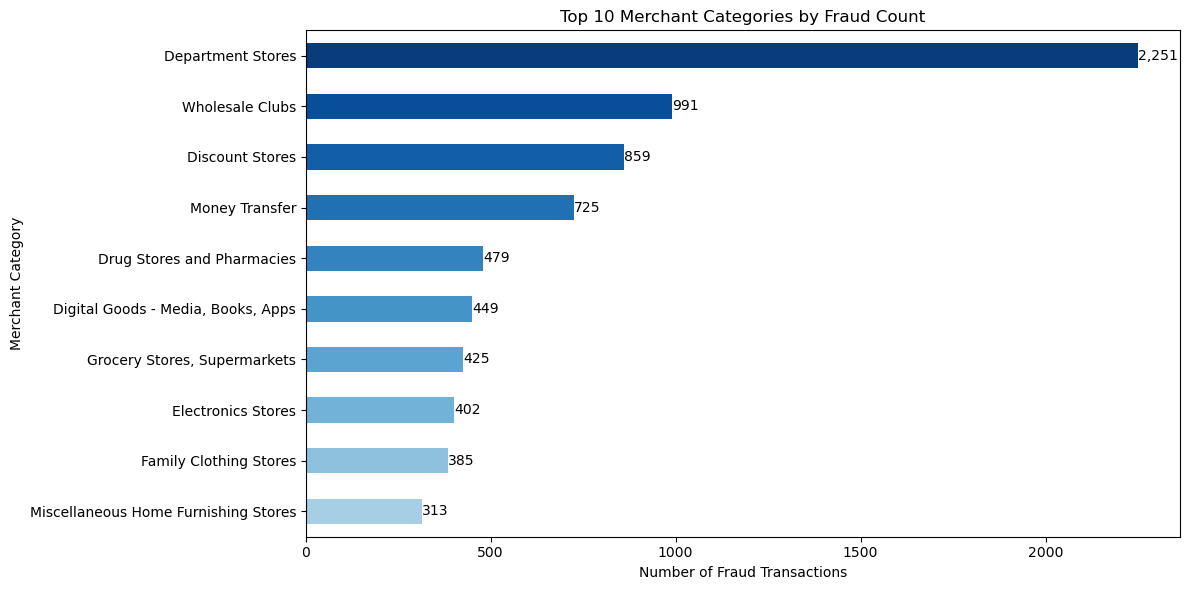

In [94]:
plt.figure(figsize=(12,6))

colors = plt.cm.Blues(np.linspace(0.35, 0.95, len(fraud_by_mcc)))

ax = fraud_by_mcc.sort_values(ascending=True).plot(
    kind='barh',
    color=colors
)

plt.title('Top 10 Merchant Categories by Fraud Count')
plt.xlabel('Number of Fraud Transactions')
plt.ylabel('Merchant Category')

for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}',
        va='center',
        ha='left'
    )

plt.tight_layout()
plt.show()

##### Fraud amount Vs Non-Fraud amount

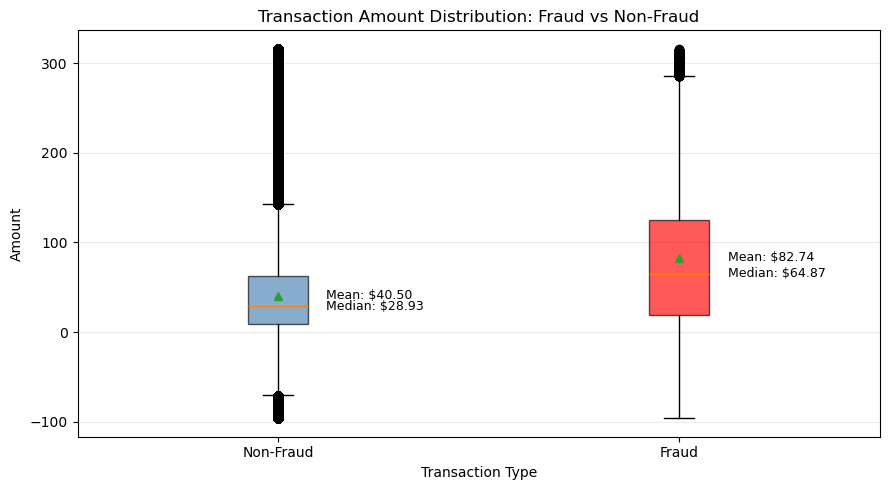

In [109]:
# Amount Distribution: Fraud vs Non-Fraud

amount_compare = fraud_merchant[
    fraud_merchant["is_fraud"].notna()
][["amount", "is_fraud"]].copy()

fraud_amounts = amount_compare[amount_compare["is_fraud"] == True]["amount"]
non_fraud_amounts = amount_compare[amount_compare["is_fraud"] == False]["amount"]

lower_limit = amount_compare["amount"].quantile(0.01)
upper_limit = amount_compare["amount"].quantile(0.99)

fraud_amounts_plot = fraud_amounts[
    (fraud_amounts >= lower_limit) & (fraud_amounts <= upper_limit)
]

non_fraud_amounts_plot = non_fraud_amounts[
    (non_fraud_amounts >= lower_limit) & (non_fraud_amounts <= upper_limit)
]

data = [non_fraud_amounts_plot, fraud_amounts_plot]
labels = ["Non-Fraud", "Fraud"]
colors = ["steelblue", "red"]

plt.figure(figsize=(9, 5))

box = plt.boxplot(
    data,
    tick_labels=labels,
    patch_artist=True,
    showmeans=True
)

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

for i, values in enumerate(data, start=1):
    mean_value = values.mean()
    median_value = values.median()

    plt.text(
        i + 0.12,
        mean_value,
        f"Mean: ${mean_value:,.2f}",
        va="center",
        fontsize=9
    )

    plt.text(
        i + 0.12,
        median_value,
        f"Median: ${median_value:,.2f}",
        va="center",
        fontsize=9,
        color="black"
    )

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Transaction Type")
plt.ylabel("Amount")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()